# Pr-YBCO version Fit modes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from importlib import reload
import C4_alris_one_third_functions as C4_alris_one_third_functions
reload(C4_alris_one_third_functions)
from C4_alris_one_third_functions import transform_list_hkl_p63_p65, get_structure_factors , atom_position_list
from matplotlib.markers import MarkerStyle
from time import time

tf.keras.utils.set_random_seed(1)

Define the function containing the fitting parameters

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- `fun_tf()` correspond to the **structure factor calculation function** (one has to convert it to a **TF-compatible** function)
- <span style="color:red">If conversion to TF-compatible function is not possible, then this approach will probably not work (or becomes much more tedious at least)</span>

In [2]:
def fn_all_hkl_list():
    all_h_list = np.linspace(0 , -4.666666 , 15)
    all_k_list = np.linspace(0 , 4.666666 , 15) 
    all_l_list = np.linspace(0 , 12 , 5) 
    all_hkl_list = np.array(np.meshgrid(all_h_list, all_k_list, all_l_list)).T.reshape(-1, 3)
    all_hkl_list = tf.convert_to_tensor(all_hkl_list, dtype=tf.float32)
    return all_hkl_list

In [3]:
def make_hkl_indices(hkl_list , experimental_data):

    
    hkl_list = np.array(hkl_list, dtype=np.float32) * 3
    hkl_list = pd.DataFrame(hkl_list, columns=['h', 'k', 'l'])

    #turn all values into integers
    hkl_list = hkl_list.astype(int)

    print('hkl')
    print(hkl_list)
    print('hkl_list shape')
    print(hkl_list.shape)

    all_h_list = np.linspace(0 , -4.666666 , 15) * 3
    all_k_list = np.linspace(0 , 4.666666 , 15) * 3
    all_l_list = np.linspace(0 , 12 , 5) * 3
    all_hkl_list = np.array(np.meshgrid(all_h_list, all_k_list, all_l_list)).T.reshape(-1, 3)
    all_hkl_list = np.round(all_hkl_list).astype(int)
    all_hkl_list = pd.DataFrame(all_hkl_list, columns=['h', 'k', 'l'])


    # all_hkl_list = all_hkl_list.astype(int)
    print('all_hkl')
    print(all_hkl_list)

    merged = all_hkl_list.merge(hkl_list, how='left', indicator=True)
    hkl_indices = merged[merged['_merge'] == 'both'].index.tolist()

    print('hkl_indices')
    print(hkl_indices)

    #retrive hkl values from all_hkl_list using hkl_indices
    hkl_from_indices = all_hkl_list.iloc[hkl_indices].values.tolist()

    print('hkl_from_indices')
    print(hkl_from_indices)

    reordered_hkl_list = pd.DataFrame(hkl_from_indices, columns=['h', 'k', 'l'])


    experimental_data[['h', 'k', 'l']] = experimental_data[['h', 'k', 'l']] * 3 
    experimental_data[['h', 'k', 'l']] = np.round(experimental_data[['h', 'k', 'l']]).astype(int)

    print('reordered_hkl_list')
    print(reordered_hkl_list)

    print('hkl_indices')
    print(hkl_indices)

    print('hkl_indices length')
    print(len(hkl_indices))

    #find the intensity values from experimental_data corresponding to the reordered_hkl_list
    intensity = []
    for index, row in reordered_hkl_list.iterrows():
        h = row['h']
        k = row['k']
        l = row['l']
        intensity_value = experimental_data[(experimental_data['h'] == h) & (experimental_data['k'] == k) & (experimental_data['l'] == l)]['intensity_exp'].values
        print('intensity_value')
        print(intensity_value)
        
        if len(intensity_value) > 0:
            intensity.append(intensity_value[0])
        else:
            intensity.append(0)

    reordered_hkl_list = np.array(hkl_from_indices, dtype=np.float32) / 3

    hkl_indices = tf.convert_to_tensor(hkl_indices, dtype=tf.int32)

    return hkl_indices , reordered_hkl_list , intensity

In [4]:
mode_num = 89
structure_type = 'C4'

path = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type

# experimental_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no0.csv')
experimental_data2 = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no_bragg.csv')

hkl_list = experimental_data2[["h", "k", "l"]].values.tolist()

print('hkl_list')
print(hkl_list)


hkl_indices , hkl_list , intensity_reordered = make_hkl_indices(hkl_list , experimental_data2)
experimental_data = pd.DataFrame(hkl_list , columns=['h', 'k', 'l'])
experimental_data['intensity_exp'] = intensity_reordered

print('reordered hkl_list')
print(hkl_list)

hkl_list = tf.convert_to_tensor(hkl_list, dtype=tf.float32)


path_matrix = path + '/C2_matrix.txt'
matrix = np.loadtxt(path_matrix, dtype=np.float32)
matrix = tf.convert_to_tensor(matrix, dtype=tf.float32)

hkl_list
[[-0.333333333, 1.0, 0.0], [-0.666666667, 1.0, 0.0], [-1.333333333, 1.0, 0.0], [-2.333333333, 1.0, 0.0], [-2.666666667, 1.0, 0.0], [-3.333333333, 1.0, 0.0], [-3.666666667, 1.0, 0.0], [-4.333333333, 1.0, 0.0], [-4.666666667, 1.0, 0.0], [-1.0, 1.333333333, 0.0], [-3.0, 1.333333333, 0.0], [-2.0, 1.666666667, 0.0], [-4.0, 1.666666667, 0.0], [-0.333333333, 2.0, 0.0], [-1.666666667, 2.0, 0.0], [-2.333333333, 2.0, 0.0], [-2.666666667, 2.0, 0.0], [-3.333333333, 2.0, 0.0], [-3.666666667, 2.0, 0.0], [-0.666666667, 2.333333333, 0.0], [-1.0, 2.333333333, 0.0], [-2.0, 2.333333333, 0.0], [-3.0, 2.333333333, 0.0], [-4.0, 2.333333333, 0.0], [-1.0, 2.666666667, 0.0], [-2.0, 2.666666667, 0.0], [-3.0, 2.666666667, 0.0], [-1.333333333, 3.0, 0.0], [-2.333333333, 3.0, 0.0], [-2.666666667, 3.0, 0.0], [-3.333333333, 3.0, 0.0], [-4.333333333, 3.0, 0.0], [-4.666666667, 3.0, 0.0], [-1.0, 3.333333333, 0.0], [-2.0, 3.333333333, 0.0], [-3.0, 3.333333333, 0.0], [-4.0, 3.333333333, 0.0], [-2.0, 3.666666667, 

Sample the "training data" (features and labels)

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The features are the (h,k,l) coordinates (e.g. a vector of size `n_features` x 3, i.e. `n_dim = 3`)
- Maybe one has to normalize the features (i.e. not using integers but floats between -1 (0) and 1)? Before passing them to the structure calculation function, they should be again rescaled to integers
- The labels would be the experimental intensities (again, maybe have to be normalized to the range between 0 and 1)

Max label ERR: 552.71216
min label ERR: 0.4453743
Features shape: (306, 3)
Labels shape: (306, 1)
error shape: (306, 1)
Max label: 2.2453024
min label : 0.0018092599


(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 2., 0., 1., 0., 0., 1., 0., 0., 0., 2., 1., 0., 0., 1., 0., 1.,
        1., 0., 1., 0., 1., 0., 1., 2., 0., 0., 0., 0., 1., 2., 1.]),
 array([0.        , 0.0458225 , 0.091645  , 0.1374675 , 0.18328999,
        0.22911249, 0.27493499, 0.32075749, 0.36657999, 0.41240249,
        0.45822499, 0.50404749, 0.54986998, 0.59569248, 0.64151498,
        0.68733748, 0.73315998, 0.77898248, 0.82480498, 0.87062748,
        0.91644997, 0.96227247, 1.00809497, 1.05391747, 1.09973997,
        1.14556247, 1.19138497, 1.23720747, 1.28302996, 1.32885246,
        1.37467496, 1.42049746, 1.46631996, 1.51214246, 1.55796496,
        1.60378746, 1.64960995, 1.69543245, 1.74125495, 1.78707745,
        1.83289995, 1.87872245, 1.92454495, 1.97036745, 2.01618994,
        2.06201244, 2.10783494, 2.15365744, 2.19947994, 2.24530244]),
 <BarContainer object of 49 artists>)

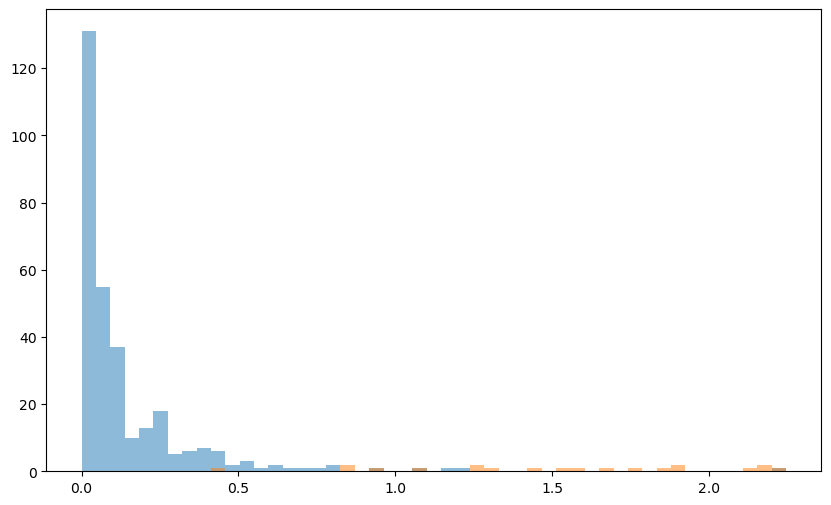

In [5]:
n_features = experimental_data.shape[0]
n_dim = 3

features = hkl_list
labels = experimental_data["intensity_exp"].tolist()
vol_err = experimental_data2["intensity_exp_err"].tolist()

#labels = np.array(labels, dtype=np.float32)
#labels = labels / np.max(labels) #Normalize labels
labels = labels / np.float32(275455.80456422985) * 10000  # Normalize to sum to 60

labels_err = []

for label, err in zip(labels, vol_err):
    if label == 0:
        labels_err.append(1e-9)  # Assign a high error for zero labels
    else:
        labels_err.append(1/label)
        # labels_err.append((label**3)  ) # Normalize error to sum to 60
        #labels_err.append(np.abs((5000 - (1/label * 100))))  # Inverse error for each label

labels_tgt = [labels, labels_err]
labels_tgt = np.transpose(labels_tgt)
labels_err = tf.convert_to_tensor(labels_err, dtype=tf.float32)
labels = tf.convert_to_tensor(labels, dtype=tf.float32)

labels = tf.expand_dims(labels, axis=-1)  # Ensure labels are 2D
labels_err = tf.expand_dims(labels_err, axis=-1)  # Ensure labels_err are 2D

print("Max label ERR:", np.max(labels_err))
print("min label ERR:", np.min(labels_err))
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print('error shape:', labels_err.shape)
print("Max label:", np.max(labels))
print("min label :", np.min(labels))
#bin from0 to 0.0025 with 50 bins
plt.figure(figsize=(10, 6))

plt.hist(labels.numpy(), bins=np.linspace(0 , np.max(labels) , 50), alpha=0.5, label='Labels')
plt.hist(labels_err.numpy(), bins=np.linspace(0 , np.max(labels) , 50), alpha=0.5, label='Labels Error')


In [6]:
def fun_tf(hkl_list, pars, matrix , hkl_indices):
    """
    Fast computation of structure factors with parameter-dependent structure.
    """
    # stack parameters
    pars_tensor = tf.stack(pars)  # shape (params,)
    norm_factors = [0.03562, 0.03562, 0.03502, 0.03502, 0.03502, 0.03562, 0.03562, 0.03502, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477, 0.03562, 0.03562, 0.03502, 0.03502, 0.03502, 0.03562, 0.03562, 0.03502, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477, 0.03562, 0.03562, 0.03502, 0.03502, 0.03502, 0.03562, 0.03562, 0.03502, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477]

    norm_factors = tf.convert_to_tensor(norm_factors, dtype=tf.float32)
    pars_tensor = pars_tensor * norm_factors
    
    pars_tensor = tf.reshape(pars_tensor, (mode_num,))  # Ensure shape is (params,)
    pars_tensor = tf.unstack(pars_tensor)

    # atom_shift_list = shift_atoms(matrix , (pars_tensor))
    # atom_shift_list = atom_shift_list[:,0]
    # atom_shift_list = tf.unstack(atom_shift_list)

    # modified_struct = atom_position_list(*atom_shift_list)

    modified_struct = atom_position_list( *pars_tensor )
    all_hkl_list = fn_all_hkl_list()
    all_hkl_list = transform_list_hkl_p63_p65(all_hkl_list)

    # Get structure factors
    sf_hkl = get_structure_factors(all_hkl_list, modified_struct)
    intensity = (abs(sf_hkl)) ** 2

    # w = tf.constant(0.000811509257682975, dtype=tf.float32)  # Debye-Waller factor 
    # qnorms = tf.norm(tf.cast(all_hkl_list, tf.float32), axis=1)
    # intensity = intensity * tf.exp(- w * qnorms ** 2)  # Apply Debye-Waller factor

    all_sim_intensity = intensity
    all_sim_intensity = all_sim_intensity / tf.reduce_sum(all_sim_intensity) * 10000

    # Extract only the intensities corresponding to the input hkl_list
    sim_intensity = tf.gather(all_sim_intensity, hkl_indices)

    return sim_intensity

Define a simple model

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The six parameters (a,b,c,d,e,f) correspond to the fractional atomic shifts in the modes w.r.t. unit cell lengths
- Instead of `sigmoid`, `tanh` should be applied to the parameters before passing them to the structure factor calculation function (ensures smoother gradient landscape)
- The `tanh` function can furthermore be limited to a specific range (e.g. if atomic distortions should not exceed +- 0.1)

In [7]:
class FunAsLayer(tf.keras.layers.Layer):
    def __init__(self, matrix , max_mode_amps,hkl_indices,**kwargs):
        super().__init__(**kwargs)
        self.max_mode_amps = max_mode_amps
        self.matrix = matrix
        self.hkl_indices = hkl_indices

    def build(self, input_shape):
        max_mode_amps = self.max_mode_amps

        self.param = (self.add_weight(name='param', shape=(mode_num,), initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.09, seed=2), trainable=True, constraint=lambda x: tf.clip_by_value(x, -max_mode_amps, max_mode_amps)))
        super().build(input_shape)

    def call(self, inputs):
        
        param = self.param 
        output = fun_tf(inputs, param, self.matrix, self.hkl_indices)
        return tf.reshape(output , [-1])  # Ensure output is 1D

Create optimizer and define loss function

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The learning rate must be determined by experimentation (same holds for the batch size and the number of epochs below)
- As a loss function, one can try either MSE or R-score (MSE seems to be the more "natural choice" in this case)

In [8]:
"""
# R-Score based on intensity
class RFactorLoss(tf.keras.losses.Loss):
    def call(self, y_true, y_pred):
        return tf.reduce_sum(tf.abs(y_true - y_pred)) / tf.reduce_sum(y_true)
"""
    
# mean squared error
class PerSampleMSELoss(tf.keras.losses.Loss):
    def __init__(self, tf_bragg_indices):
        self.tf_bragg_indices = tf_bragg_indices
        super().__init__(reduction=tf.keras.losses.Reduction.NONE)

    def call(self, y_true, y_pred):
        #retrieve y_pred values at bragg indices
        print('y_pred shape:', y_pred.shape)
        if y_pred.shape != (None,):
            y_pred_bragg = tf.gather(y_pred, self.tf_bragg_indices)
            # y_true = tf.expand_dims(y_true, axis=-1)

            print('before update loss y_true')
            print("y_pred_bragg shape:", y_pred_bragg.shape)
            print("y_true shape:", y_true.shape)
            print("tf_bragg_indices shape:", self.tf_bragg_indices.shape)


            # let squared error be zero for bragg indices
            y_true_loss = tf.tensor_scatter_nd_update(y_true , self.tf_bragg_indices , y_pred_bragg)
            print('updated loss y_true')
            print("y_true_loss shape:", y_true_loss.shape)
            y_true_loss = tf.squeeze(y_true_loss, axis=-1)
            print("y_true_loss shape after squeeze:", y_true_loss.shape)
        else:
            y_true_loss = y_true
            print('not updated loss y_true')

        squared_error = tf.square(y_true_loss - y_pred)
        per_sample_mse = tf.reduce_mean(squared_error, axis=-1)
        return per_sample_mse  # shape (batch_size,)

class WeightedMeanSquaredError(tf.keras.losses.Loss):
    def __init__(self,reduction=tf.keras.losses.Reduction.AUTO, name='WeightedMeanSquaredError'):
        super(WeightedMeanSquaredError, self).__init__(reduction=reduction, name=name)

    def call(self, y_true, y_pred):
        mse = tf.keras.losses.mean_squared_error(y_true, y_pred)
        return mse

    def num_of_elements(self, sample_weight):
        return tf.size(sample_weight).numpy()
    
    def __call__(self, y_true, y_pred,sample_weight):
        #return super().__call__(y_true, y_pred, 1)
        # 1/n *  sum(weights * mse(y_p - y_t))
        actual_loss = super().__call__(y_true, y_pred)
        num_of_el = tf.py_function(func=self.num_of_elements, inp = [sample_weight], Tout=tf.float32)

        # dividing by sum of all weights in this batch
        # (sum(weights * mse(y_p - y_t))) / sum(weights)
        wmse_loss = actual_loss * (num_of_el / tf.math.reduce_sum(sample_weight))
        return wmse_loss
  

class RFactorLoss(tf.keras.losses.Loss):
    def call(self, y_true, y_pred):
        print('ytrue shape in loss:', y_true.shape)
        y_true = tf.reshape(y_true, [-1])
        print('ytrue reshaped shape in loss:', y_true.shape)
        print('ypred shape in loss:', y_pred.shape)
        print('ytrue values in loss:', y_true)
        return tf.reduce_sum(tf.abs(tf.sqrt(y_true) - tf.sqrt(y_pred))) / tf.reduce_sum(tf.sqrt(y_true))
    
    
# # Define the custom metric function
# def r_factor_metric(y_true, y_pred):
#     y_true = tf.reshape(y_true, [-1])
#     return tf.reduce_sum(tf.abs(y_true - y_pred)) / tf.reduce_sum(tf.abs(y_true))

def r_factor_metric(y_true, y_pred):
    y_true = tf.reshape(y_true, [-1])
    return tf.reduce_sum(tf.abs(tf.sqrt(y_true) - tf.sqrt(y_pred))) / tf.reduce_sum(tf.sqrt(y_true))


Train the model for n iterations (to try different initial weights)

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The number of iterations defines the "starting position" $w_0$ of the gradient descent algorithm
- Because there are probably many local minima, changing $w_0$ allows the algorithm to find different minima and increases the chances of finding the global minima

Learning rate: 0.004
(89,)
Final loss: 1.142e-01
Iteration 1 - New best loss: 1.142e-01 (R-factor: 2.560e-01)
time elapsed: 13.45 seconds
With 37.164360986345436 iterations per second


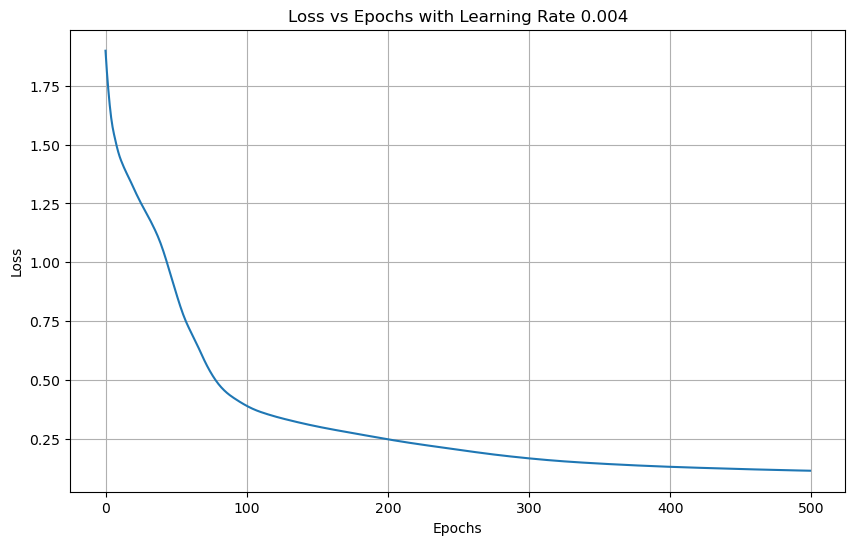

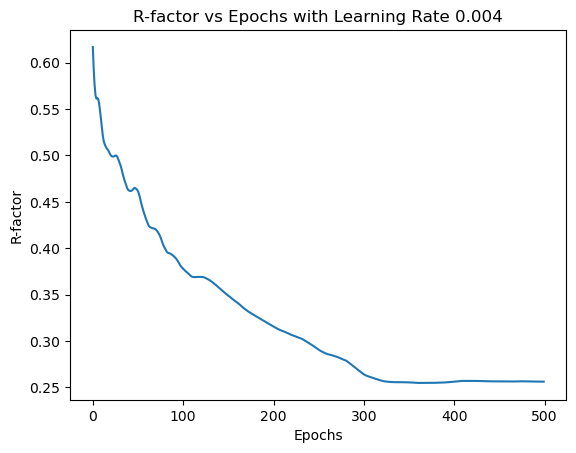

Best R-factor for learning rate 0.004: 2.560e-01


In [9]:
lr = [4e-3]
best_pars_overall = None
best_rf_overall = np.inf
best_loss_overall = []
norm_factors = [0.03562, 0.03562, 0.03502, 0.03502, 0.03502, 0.03562, 0.03562, 0.03502, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477, 0.03562, 0.03562, 0.03502, 0.03502, 0.03502, 0.03562, 0.03562, 0.03502, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477, 0.03562, 0.03562, 0.03502, 0.03502, 0.03502, 0.03562, 0.03562, 0.03502, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477]
norm_factors = tf.convert_to_tensor(norm_factors, dtype=tf.float32)

for learning_rate in lr:
    time_start = time()
    print(f"Learning rate: {learning_rate}")
    optim = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    path_max_mode_amps = path + '/PBCO_1_3_' + structure_type + '_max_bound_vectors.txt'
    max_mode_amps = np.loadtxt(path_max_mode_amps, dtype=np.float32 , delimiter=',')

    # # indices_to_zero = [9, 41, 52, 44, 47, 37, 2, 63, 28, 76, 56, 3, 12, 30, 32, 82, 73, 79, 50, 74, 75, 13, 70, 19, 88, 94, 38, 55, 34, 57, 102, 72, 86, 92, 46, 101, 4, 22, 90, 24, 5, 58, 62, 10, 99, 17, 71, 1, 59, 93, 100, 53, 49, 60, 26, 7, 14, 11, 98, 77, 23, 29, 66, 36, 40, 69, 83, 97, 18, 91, 67, 43, 81, 64, 6]
    # indices_to_zero = [2 , 4 , 6 , 8 , 12 , 13 , 19 , 20 , 21 , 22 , 23 , 45 , 46 , 47 , 48 , 16 , 17 , 30 , 34 , 43 , 58 , 67 , 99 , 100 , 1 , 39 , 57 , 59 , 97, 24, 40   , 61 , 70 , 14 , 84 , 72 , 10 , 69 ,95 , 28 , 85 , 15 , 88, 92 , 83 , 91 , 66 , 74, 101, 87, 56 , 89, 42 , 86 , 35 , 73 , 79, 26, 53 , 55]
    # for index in indices_to_zero:
    #     max_mode_amps[index - 1] = 0.0

    # print('length of indices_to_zero:', len(indices_to_zero))

    max_mode_amps = tf.convert_to_tensor(max_mode_amps, dtype=tf.float32)

    n_epochs = 500
    histories = []
    n_iter = 1

    min_loss = np.inf
    best_pars = None
    # List to store the loss values for each epoch
    all_losses = []
    all_rfs = []

    for i in range(n_iter):
        # Create the model
        inputs = tf.keras.Input(shape=(n_dim,))
        outputs = FunAsLayer(matrix , max_mode_amps , hkl_indices)(inputs)
        model = tf.keras.Model(inputs, outputs)

        initial_weights = model.layers[-1].get_weights()[0] * norm_factors

        # Compile the model with the custom loss function and metric
        model.compile(
            optimizer=optim,
            loss= 'mse', # MSE_weighted() if using errors
            metrics=[r_factor_metric],
            run_eagerly=False,  # Set to True for debugging, False for performance

        )
        
        history = model.fit(
        x=features,
        y=labels,  # replace with combined_labels if using errors
        batch_size = features.shape[0], # Use a smaller batch size features.shape[0]
        epochs=n_epochs,
        verbose=0,
        shuffle=False, # not sure whether this matters (THIS MATTERS actually lmao, always set to false -alris)
        # callbacks=[cb]
        sample_weight=labels_err  # Use sample weights if you have errors
        )

        histories.append(history)
        all_losses.append(history.history['loss'])
        all_rfs.append(history.history['r_factor_metric'])

        # Check final loss
        final_loss = history.history['loss'][-1]
        print(model.layers[-1].get_weights()[0].shape)
        curren_model_pars = (model.layers[-1].get_weights()[0])

        print(f"Final loss: {final_loss:.3e}")

        if final_loss < min_loss:
            # Update best model parameters
            best_model_pars = model.layers[-1].get_weights()[0]
            min_loss = final_loss
            rf = r_factor_metric(labels, fun_tf(features, best_model_pars , matrix, hkl_indices))
            print(f"Iteration {i+1} - New best loss: {min_loss:.3e} (R-factor: {rf:.3e})")

    if min_loss < best_rf_overall:
        best_rf_overall = min_loss
        best_pars_overall = best_model_pars
        best_loss_overall = all_losses
    print(f"time elapsed: {time() - time_start:.2f} seconds")
    print(f"With {n_epochs*n_iter /(time() - time_start)} iterations per second")
    # Plotting the loss values
    plt.figure(figsize=(10, 6))

    # Plot the loss values for each iteration
    for i, loss_values in enumerate(all_losses):
        plt.plot(loss_values, label=f'Iteration {i+1}')
    
    plt.title(f'Loss vs Epochs with Learning Rate {learning_rate}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    # plt.legend()
    plt.grid(True)
    plt.show()

    for i , rf_values in enumerate(all_rfs):
        plt.plot(rf_values, label=f'R-factor Iteration {i+1}')
    
    plt.title(f'R-factor vs Epochs with Learning Rate {learning_rate}')
    plt.xlabel('Epochs')
    plt.ylabel('R-factor')
    plt.show()

    y_pred = fun_tf(features, best_model_pars , matrix , hkl_indices)
    rf = r_factor_metric(labels, y_pred)
    print(f"Best R-factor for learning rate {learning_rate}: {rf:.3e}")
    final_weights = model.layers[-1].get_weights()[0] * norm_factors

In [10]:
all_losses = best_loss_overall
best_model_pars = best_pars_overall
min_loss = best_rf_overall

print(f"min loss: {min_loss}")
print(f"r_factor: {rf}")

# # Plotting the loss values
# plt.figure(figsize=(10, 6))

# # Plot the loss values for each iteration
# for i, loss_values in enumerate(all_losses):
#     plt.plot(loss_values, label=f'Iteration {i+1}')

# plt.title('Loss vs Epochs')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# # plt.legend()
# plt.grid(True)
# plt.show()

min loss: 0.11424413323402405
r_factor: 0.25599008798599243


C:\Users\User\AppData\Local\Temp\ipykernel_21792\323913097.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;b,0)[Pr1:h:dsp]B3u(a) : 0.04992209
mode a2 Pmmm[1/3,1/3,0]V1(a,0;b,0)[Pr1:h:dsp]B3u(b) : 0.01431841
mode a3 Pmmm[1/3,1/3,0]V1(a,0;b,0)[Pr1:h:dsp]B2u(a) : -0.28855628
mode a4 Pmmm[1/3,1/3,0]V1(a,0;b,0)[Pr1:h:dsp]B2u(b) : 0.01595919
mode a5 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.01238045
mode a6 Pmmm[0,1/3,0]DT4(0,a)[Pr1:h:dsp]B3u(a) : -0.00101482
mode a7 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00251930
mode a8 Pmmm[1/3,0,0]SM4(0,a)[Pr1:h:dsp]B2u(a) : -0.02086518
mode a9 Pmmm[1/3,1/3,0]V1(a,0;b,0)[Ba1:t:dsp]A1(a) : -0.02119121
mode a10 Pmmm[1/3,1/3,0]V1(a,0;b,0)[Ba1:t:dsp]A1(b) : 0.01081821
mode a11 Pmmm[1/3,1/3,0]V1(a,0;b,0)[Ba1:t:dsp]B2(a) : 0.25530663
mode a12 Pmmm[1/3,1/3,0]V1(a,0;b,0)[Ba1:t:dsp]B2(b) : 0.02005571
mode a13 Pmmm[1/3,1/3,0]V1(a,0;b,0)[Ba1:t:dsp]B1(a) : -0.00377029
mode a14 Pmmm[1/3,1/3,0]V1(a,0;b,0)[Ba1:t:dsp]B1(b) : -0.00258186
mode a15 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : -0.05357686
mode a16 Pmmm[0,1/3,0]

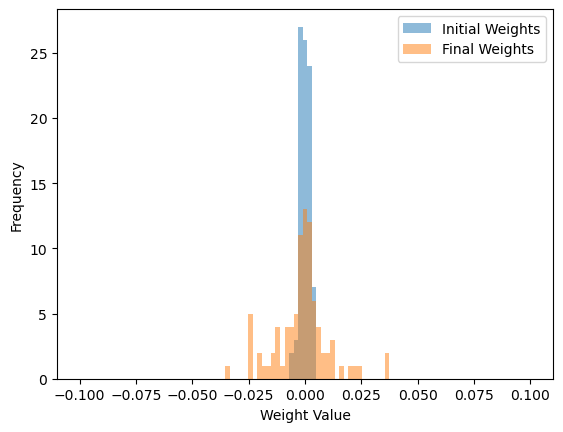

In [14]:
path_displacive_modes = path + '/PBCO_1_3_' + structure_type + '_displacive_modes.txt'
norm_factors = [0.03562, 0.03562, 0.03502, 0.03502, 0.03502, 0.03562, 0.03562, 0.03502, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477, 0.03562, 0.03562, 0.03502, 0.03502, 0.03502, 0.03562, 0.03562, 0.03502, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477, 0.03562, 0.03562, 0.03502, 0.03502, 0.03502, 0.03562, 0.03562, 0.03502, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477, 0.02853, 0.02853, 0.02477, 0.02477, 0.02519, 0.02519, 0.02017, 0.02853, 0.02477, 0.02519, 0.02853, 0.02519, 0.02477]


mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)
mode_names = mode_names.values.tolist()
mode_names = pd.DataFrame(mode_names)

# Print the best model parameters
print("Best model parameters:") 
for i, par in enumerate(best_model_pars):
    print(f"mode a{i+1} {mode_names.iloc[i, 1]} : {par / max_mode_amps[i]:.8f}")

# smallest absolute mode amp

smallest_mode_amp = np.min(np.abs(best_model_pars[np.nonzero(best_model_pars)]))
smallest_mode_name = np.where(np.abs(best_model_pars) == smallest_mode_amp)[0][0]
print(f"Smallest mode amplitude (non-zero): {smallest_mode_amp:.8f}")
print(f"Smallest mode name: mode a{smallest_mode_name + 1} {mode_names.iloc[smallest_mode_name, 1]}")

list_modes_removal = np.abs(best_model_pars) / max_mode_amps

plt.hist(initial_weights, bins=np.linspace(-0.1 , 0.1 , 100), alpha=0.5, label='Initial Weights')
plt.hist(final_weights , bins=np.linspace(-0.1 , 0.1 , 100), alpha=0.5, label='Final Weights')
# plt.hist(best_model_pars * max_mode_amps, bins=np.linspace(-1.5 , 1.5 , 50), alpha=0.5, label='Best Weights')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [15]:
def alris_r_factor(data):
    # exp_intensity = data['normalised_exp']
    exp_intensity = data['normalised_exp']
    simulated_intensity = data['intensity_sim']
    alris_r_factor = np.sum(np.abs(np.sqrt(exp_intensity) - np.sqrt(simulated_intensity))) / np.sum(np.sqrt(exp_intensity))
    return alris_r_factor


def plot_plane_sim_vs_exp_DIM3(ax, df, r_factor, l, norm_plane=False):
    if norm_plane == True:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 100
    exp_data_0 = df.loc[df['l'] == l].copy()

    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 1000 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['normalised_exp'] + 1)* 1000 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    # ax.scatter(exp_data_0['h'], exp_data_0['k'], 
    #         s=exp_data_0['intensity_sim'] * 100, color='red', edgecolor="black",
    #         label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    # ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=exp_data_0['normalised_exp'] * 100, color='blue', edgecolor="black",
    #         label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = {l} (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

def plot_plane_sim_vs_exp_DIM3_no_bragg(ax, df, r_factor, l, norm_plane=False):
    # exp_data_0 = df.loc[df['l'] == l].copy()
    # #copy the dataframe and remove rows where h and k are both integer
    # exp_data_0 = exp_data_0[~((exp_data_0['h'] % 1 == 0) & (exp_data_0['k'] % 1 == 0))]
    if norm_plane == True:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 100
    exp_data_0 = df.loc[df['l'] == l].copy()
    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 1000 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['intensity_exp'] + 1) * 1000 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = {l} (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

ALRIS R-factor: 0.256


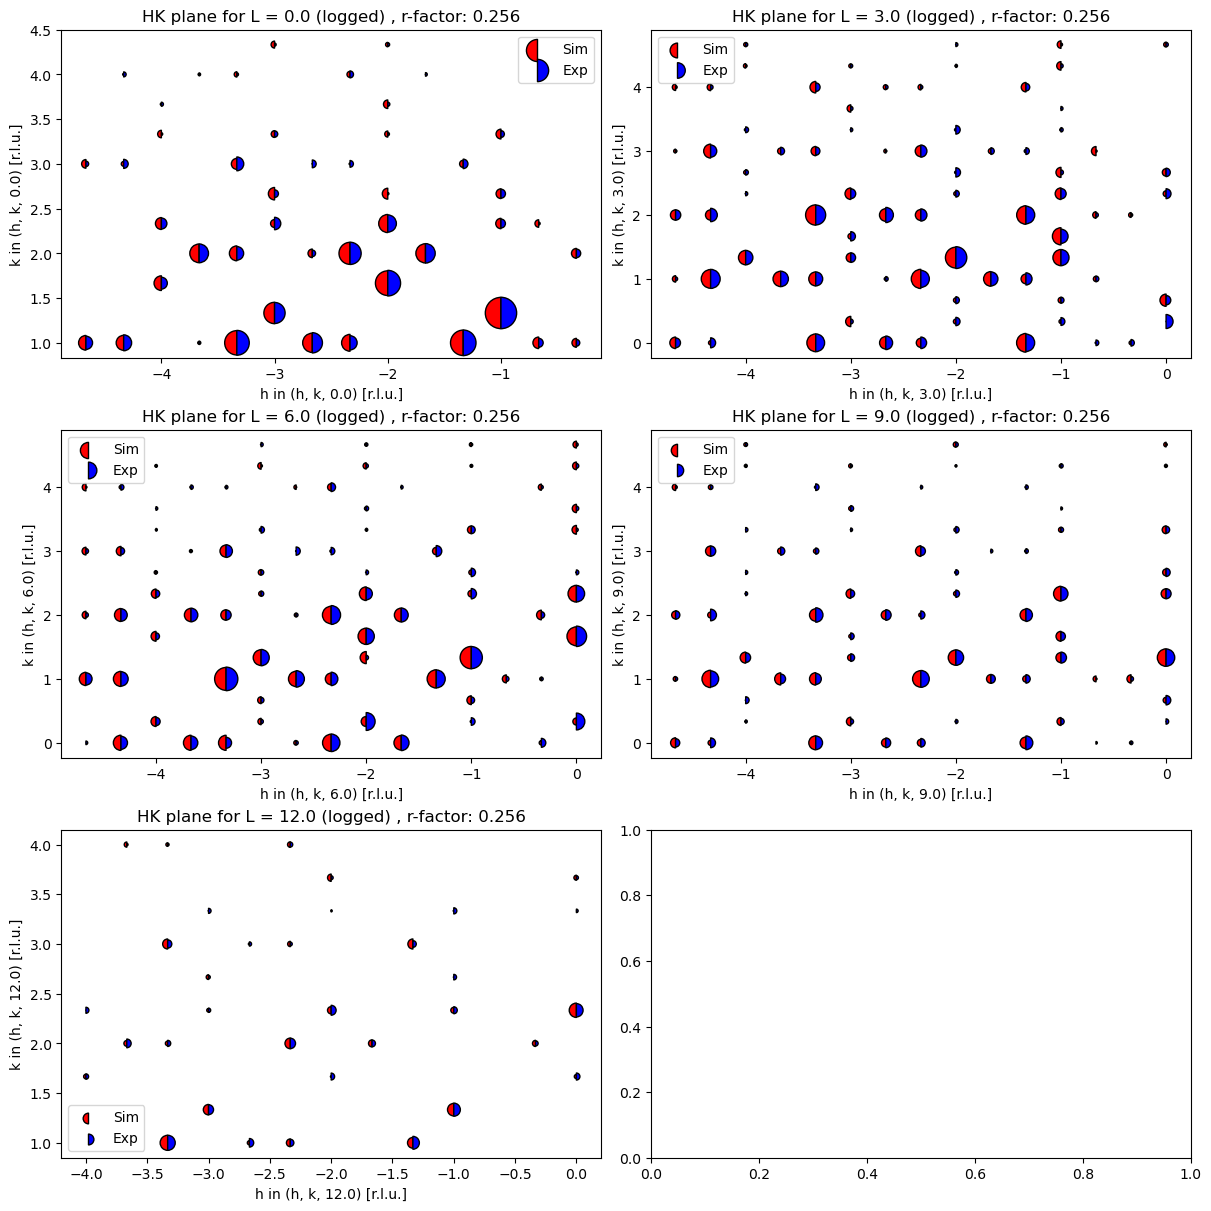

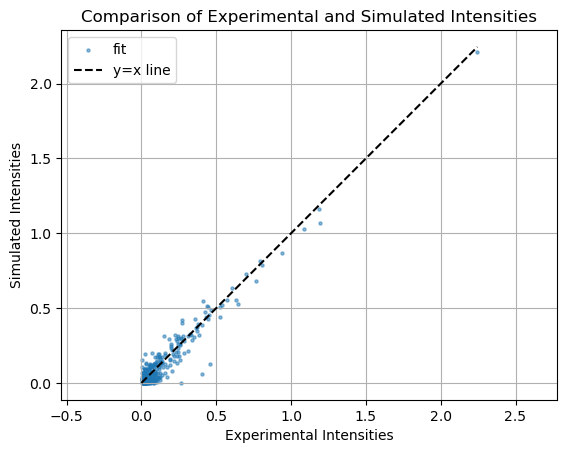

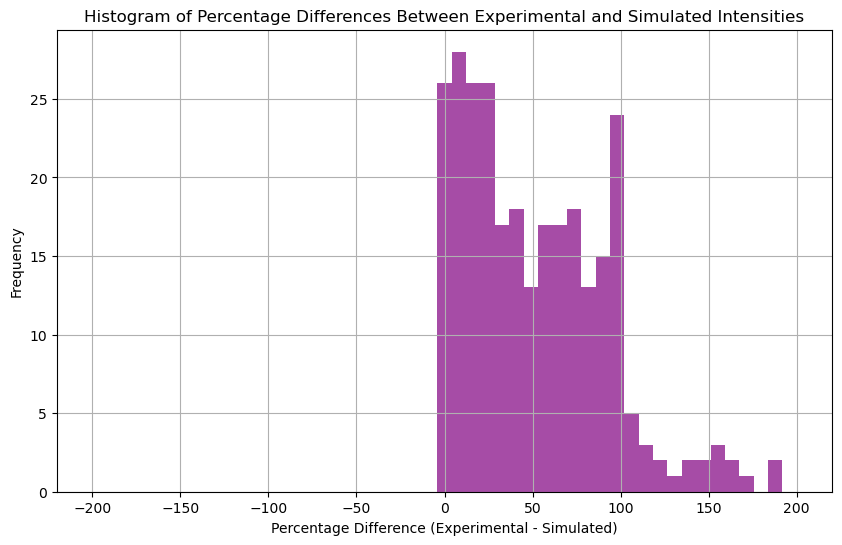

In [16]:
# # exp_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no0.csv')
# exp_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no_bragg.csv')

exp_data = experimental_data.copy()


exp_data['intensity_sim'] = fun_tf(features, best_model_pars, matrix, hkl_indices).numpy()


normalised_exp_data = exp_data['intensity_exp'] /  np.float32(275455.80456422985) * 10000
exp_data['normalised_exp'] = normalised_exp_data
exp_data['intensity_exp_err'] = labels_err.numpy()

r_factor = alris_r_factor(exp_data)
print(f"ALRIS R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = normalised_exp_data

x = np.linspace(0 ,max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
# plt.xlim(0 , 1.2)
# plt.ylim(0 , 1.0)
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()